In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os
import IPython.display as ipd
from scipy.io.wavfile import write

In [2]:
for root, _, files in os.walk("MIT KEMAR Dataset"):
    print(root)
    for file in files:
        pass

MIT KEMAR Dataset
MIT KEMAR Dataset\elev-10
MIT KEMAR Dataset\elev-20
MIT KEMAR Dataset\elev-30
MIT KEMAR Dataset\elev-40
MIT KEMAR Dataset\elev0
MIT KEMAR Dataset\elev10
MIT KEMAR Dataset\elev20
MIT KEMAR Dataset\elev30
MIT KEMAR Dataset\elev40
MIT KEMAR Dataset\elev50
MIT KEMAR Dataset\elev60
MIT KEMAR Dataset\elev70
MIT KEMAR Dataset\elev80
MIT KEMAR Dataset\elev90


In [4]:
RUTA = os.path.join("MIT KEMAR Dataset\elev50\L50e152a.wav")

audio_data, sr= librosa.load(path= RUTA,
                          sr= 44100)
time_audio_data = np.linspace(0, len(audio_data) / sr, num=len(audio_data))

ipd.Audio(RUTA)

la duración de esta respuesta al impulso en particular es de 0.011609977324263039 segundos, con 512 muestras


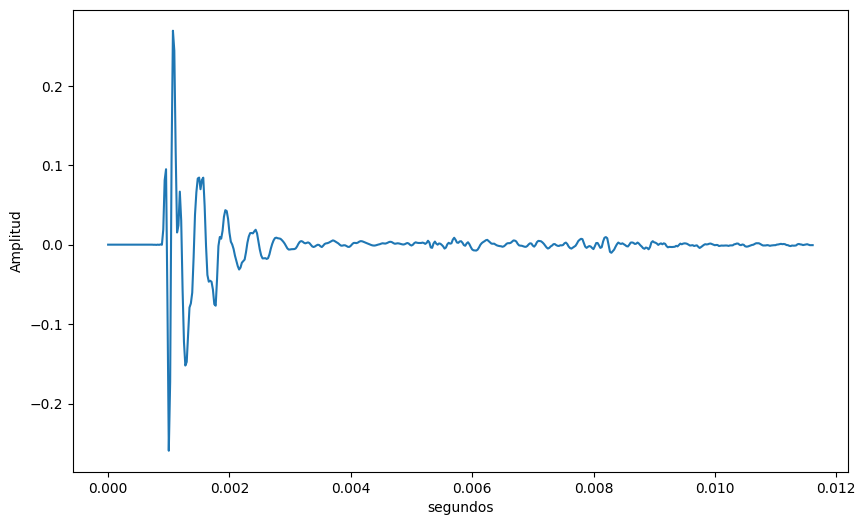

In [6]:
FIG_SIZE = (10,6)
plt.figure(figsize=FIG_SIZE)
plt.plot(time_audio_data, audio_data)
plt.ylabel("Amplitud") # El eje x es Time por defecto
plt.xlabel("segundos")

duracion = len(audio_data)/sr
muestras = len(audio_data)
print(f'la duración de esta respuesta al impulso en particular es de {duracion} segundos, con {muestras} muestras')

Text(0.5, 0, 'Frecuencia')

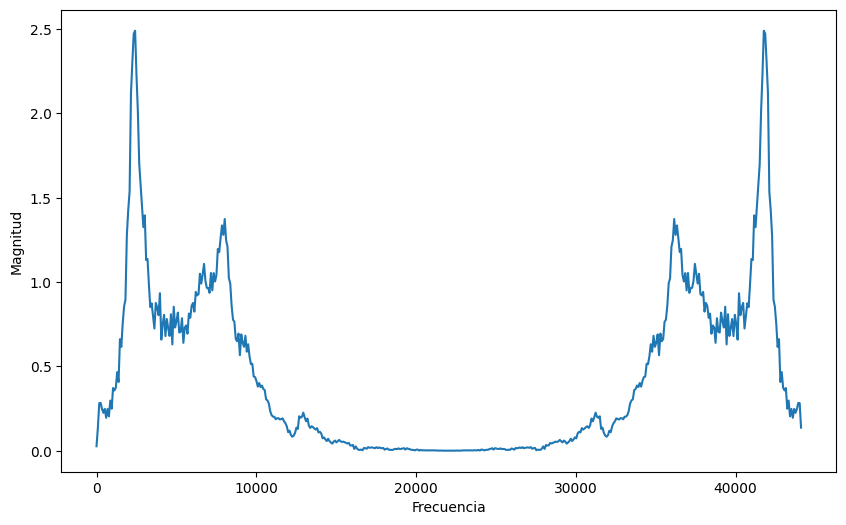

In [68]:
fft = np.fft.fft(audio_data) # FFT -> Fast Fourier Transform

magnitud = np.abs(fft) 
# Obtenemos los valores absolutos de ftt para ver que frecuencia contribuye más al sonido

frecuencia = np.linspace(0, sr, len(magnitud))
# generamos numeros equidistantes entre 0 y sr para mapear la magnitud
plt.figure(figsize=FIG_SIZE)
plt.plot(frecuencia, magnitud)
plt.ylabel("Magnitud")
plt.xlabel("Frecuencia")

Text(0, 0.5, 'Magnitud')

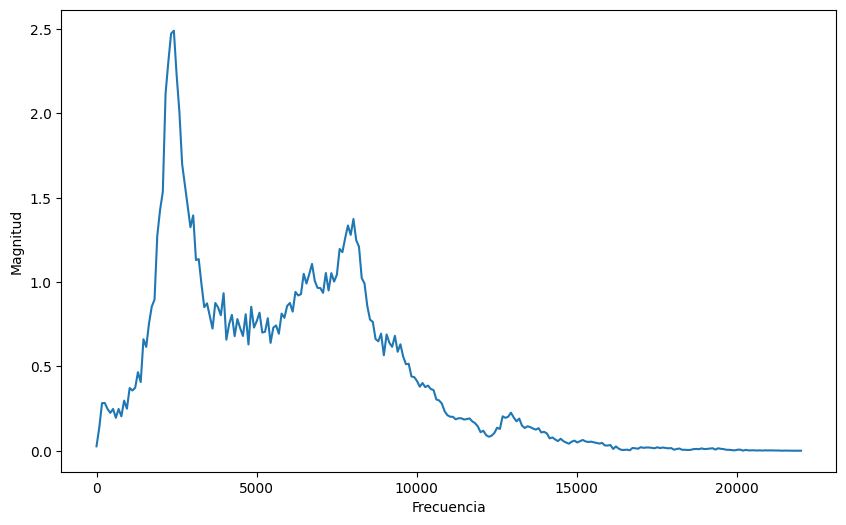

In [69]:
frecuencia_isq = frecuencia[:int(len(frecuencia)/2)]
magnitud_isq = magnitud[:int(len(frecuencia)/2)]


plt.figure(figsize=FIG_SIZE)
plt.plot(frecuencia_isq, magnitud_isq)
plt.xlabel("Frecuencia")
plt.ylabel("Magnitud")

Text(0, 0.5, 'Magnitud')

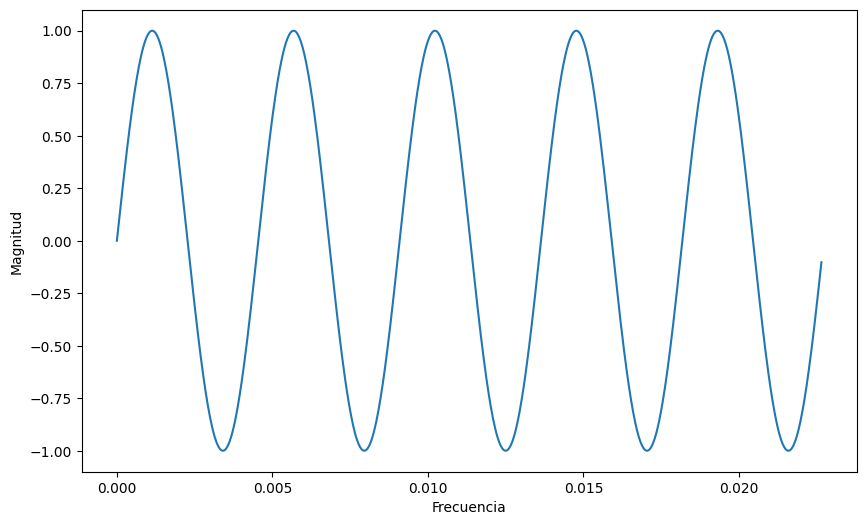

In [70]:
fs = 44100

t = np.linspace(0, 3, int(3 * fs), endpoint=False) 

seno = np.sin(2*np.pi *220*t)

plt.figure(figsize=FIG_SIZE)
plt.plot(t[0:1000], seno[0:1000])
plt.xlabel("Frecuencia")
plt.ylabel("Magnitud")


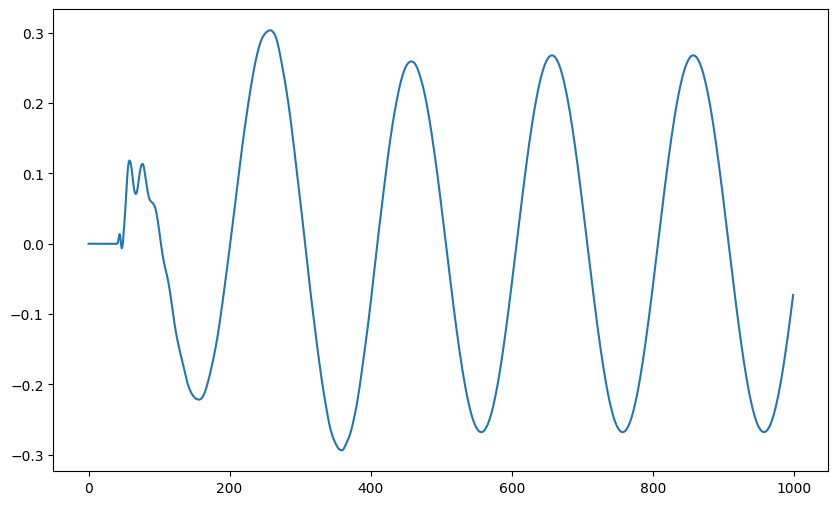

In [73]:
convolucion = np.convolve(seno, audio_data, mode= 'full')

plt.figure(figsize=FIG_SIZE)
plt.plot(convolucion[0:1000])

In [55]:
write("resultado_salida.wav", fs, seno.astype(np.float32))

# Reproducir el audio en la misma notebook
ipd.Audio(seno, rate=fs)

In [64]:
write("resultado_salida.wav", fs, convolucion.astype(np.float32))

# Reproducir el audio en la misma notebook
ipd.Audio(convolucion, rate=fs) 
